In [60]:
import pandas as pd

In [61]:
df = pd.read_csv("final.csv")

In [62]:
df

,Body_Type,Kilometers,Owners,Brand,Model,Model_Year,Price(Lakhs),Fuel_Type,Seats,City
0,Hatchback,120000,3,Maruti,Maruti Celerio,2015,4.00,Petrol,5,Banglore
1,SUV,32706,2,Ford,Ford Ecosport,2018,8.11,Petrol,5,Banglore
2,Hatchback,11949,1,Tata,Tata Tiago,2018,5.85,Petrol,5,Banglore
3,Sedan,17794,1,Hyundai,Hyundai Xcent,2014,4.62,Petrol,5,Banglore
4,SUV,60000,1,Maruti,Maruti SX4 S Cross,2015,7.90,Diesel,5,Banglore
...,...,...,...,...,...,...,...,...,...,...
5701,Hatchback,10000,1,Maruti,Maruti Celerio,2022,5.10,Petrol,5,Kolkata
5702,Hatchback,120000,1,Maruti,Maruti Alto 800,2014,1.80,Petrol,5,Kolkata
5703,Sedan,50000,3,Mercedes-Benz,Mercedes-Benz C-Class,2011,5.50,Petrol,5,Kolkata
5704,Hatchback,40000,1,Maruti,Maruti Ritz,2012,1.40,Petrol,5,Kolkata


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5706 entries, 0 to 5705
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Body_Type     5704 non-null   object 
 1   Kilometers    5706 non-null   int64  
 2   Owners        5706 non-null   int64  
 3   Brand         5706 non-null   object 
 4   Model         5706 non-null   object 
 5   Model_Year    5706 non-null   int64  
 6   Price(Lakhs)  5706 non-null   float64
 7   Fuel_Type     5706 non-null   object 
 8   Seats         5706 non-null   int64  
 9   City          5706 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 445.9+ KB


In [64]:
for i in df.select_dtypes(include='object').columns:
    print(i,len(df[i].unique()))

Body_Type 11
Brand 32
Model 288
Fuel_Type 5
City 4


In [65]:
label_cols = ["Body_Type", "Fuel_Type", "City"]
onehot_cols = ["Brand", "Model"]

In [66]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

oe = OneHotEncoder(sparse_output=False)
# OneHot Encoding for selected columns
model_encoded = oe.fit_transform(df[onehot_cols])
model_cols = oe.get_feature_names_out(onehot_cols)
model_df = pd.DataFrame(model_encoded, columns=model_cols)
model_df.index = df.index

# Merge with original DataFrame
df = pd.concat([df.drop(onehot_cols, axis=1), model_df], axis=1)


In [67]:
model_cols,len(model_cols)

(array(['Brand_Audi', 'Brand_BMW', 'Brand_Chevrolet', 'Brand_Citroen',
        'Brand_Datsun', 'Brand_Fiat', 'Brand_Ford',
        'Brand_Hindustan Motors', 'Brand_Honda', 'Brand_Hyundai',
        'Brand_Isuzu', 'Brand_Jaguar', 'Brand_Jeep', 'Brand_Kia',
        'Brand_Land Rover', 'Brand_Lexus', 'Brand_MG', 'Brand_Mahindra',
        'Brand_Mahindra Renault', 'Brand_Mahindra Ssangyong',
        'Brand_Maruti', 'Brand_Mercedes-Benz', 'Brand_Mini',
        'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Porsche',
        'Brand_Renault', 'Brand_Skoda', 'Brand_Tata', 'Brand_Toyota',
        'Brand_Volkswagen', 'Brand_Volvo', 'Model_Ambassador',
        'Model_Audi A3', 'Model_Audi A3 cabriolet', 'Model_Audi A4',
        'Model_Audi A6', 'Model_Audi A8', 'Model_Audi Q2', 'Model_Audi Q3',
        'Model_Audi Q3 Sportback', 'Model_Audi Q5', 'Model_Audi Q7',
        'Model_Audi S5 Sportback', 'Model_BMW 1 Series',
        'Model_BMW 2 Series', 'Model_BMW 3 Series',
        'Model_BMW 3 Series GT',

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5706 entries, 0 to 5705
Columns: 328 entries, Body_Type to Model_Volvo XC60
dtypes: float64(321), int64(7)
memory usage: 14.3 MB


In [69]:
df

,Body_Type,Kilometers,Owners,Model_Year,Price(Lakhs),Fuel_Type,Seats,City,Brand_Audi,Brand_BMW,...,Model_Volkswagen Vento,Model_Volkswagen Virtus,Model_Volvo S 80,Model_Volvo S60,Model_Volvo S60 Cross Country,Model_Volvo S90,Model_Volvo V40,Model_Volvo XC 90,Model_Volvo XC40,Model_Volvo XC60
0,2,120000,3,2015,4.00,4,5,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7,32706,2,2018,8.11,4,5,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,11949,1,2018,5.85,4,5,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8,17794,1,2014,4.62,4,5,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,60000,1,2015,7.90,1,5,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5701,2,10000,1,2022,5.10,4,5,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5702,2,120000,1,2014,1.80,4,5,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5703,8,50000,3,2011,5.50,4,5,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5704,2,40000,1,2012,1.40,4,5,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
x = df.drop("Price(Lakhs)",axis =1)
y = df["Price(Lakhs)"]

In [71]:
x

,Body_Type,Kilometers,Owners,Model_Year,Fuel_Type,Seats,City,Brand_Audi,Brand_BMW,Brand_Chevrolet,...,Model_Volkswagen Vento,Model_Volkswagen Virtus,Model_Volvo S 80,Model_Volvo S60,Model_Volvo S60 Cross Country,Model_Volvo S90,Model_Volvo V40,Model_Volvo XC 90,Model_Volvo XC40,Model_Volvo XC60
0,2,120000,3,2015,4,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7,32706,2,2018,4,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,11949,1,2018,4,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8,17794,1,2014,4,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,60000,1,2015,1,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5701,2,10000,1,2022,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5702,2,120000,1,2014,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5703,8,50000,3,2011,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5704,2,40000,1,2012,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler = MinMaxScaler()
x_train['Kilometers'] = scaler.fit_transform(x_train[['Kilometers']])
x_test['Kilometers'] = scaler.transform(x_test[['Kilometers']])

In [73]:
scaler.data_min_

array([101.])

In [74]:
x_train

,Body_Type,Kilometers,Owners,Model_Year,Fuel_Type,Seats,City,Brand_Audi,Brand_BMW,Brand_Chevrolet,...,Model_Volkswagen Vento,Model_Volkswagen Virtus,Model_Volvo S 80,Model_Volvo S60,Model_Volvo S60 Cross Country,Model_Volvo S90,Model_Volvo V40,Model_Volvo XC 90,Model_Volvo XC40,Model_Volvo XC60
1818,7,0.007618,1,2018,1,5,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5386,7,0.001618,1,2021,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2224,2,0.012670,2,2017,4,5,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4995,2,0.005073,1,2015,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1071,4,0.007254,1,2019,4,7,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,2,0.009255,1,2019,0,5,2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5191,2,0.012709,1,2014,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5226,8,0.010010,1,2015,1,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,8,0.009073,1,2016,4,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
# model1 = RandomForestRegressor()  
# model1.fit(x_train, y_train)     
# y_pred=model1.predict(x_test)
# print(mean_squared_error(y_test,y_pred)) 
# print(mean_absolute_error(y_test,y_pred)) 
# print(r2_score(y_test,y_pred))

In [77]:
# model2 = DecisionTreeRegressor()  
# model2.fit(x_train, y_train)     
# y_pred=model2.predict(x_test)
# print(mean_squared_error(y_test,y_pred)) 
# print(mean_absolute_error(y_test,y_pred)) 
# print(r2_score(y_test,y_pred))

In [78]:
# model3 = GradientBoostingRegressor()  
# model3.fit(x_train, y_train)     
# y_pred=model3.predict(x_test)
# print(mean_squared_error(y_test,y_pred)) 
# print(mean_absolute_error(y_test,y_pred)) 
# print(r2_score(y_test,y_pred))

In [79]:
models = [RandomForestRegressor(), DecisionTreeRegressor(),GradientBoostingRegressor()]


In [80]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Train the model
    model.fit(x_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(x_test)
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Print results
    print(f"Model: {model.__class__.__name__}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.2f}")
    print("-" * 40)

    # Plot Actual vs Predicted Prices
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(f'{type(model).__name__}: Actual vs Predicted Prices')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
    plt.show()

Model: RandomForestRegressor
Mean Squared Error: 47.50
Mean Absolute Error: 1.80
R2 Score: 0.85
----------------------------------------


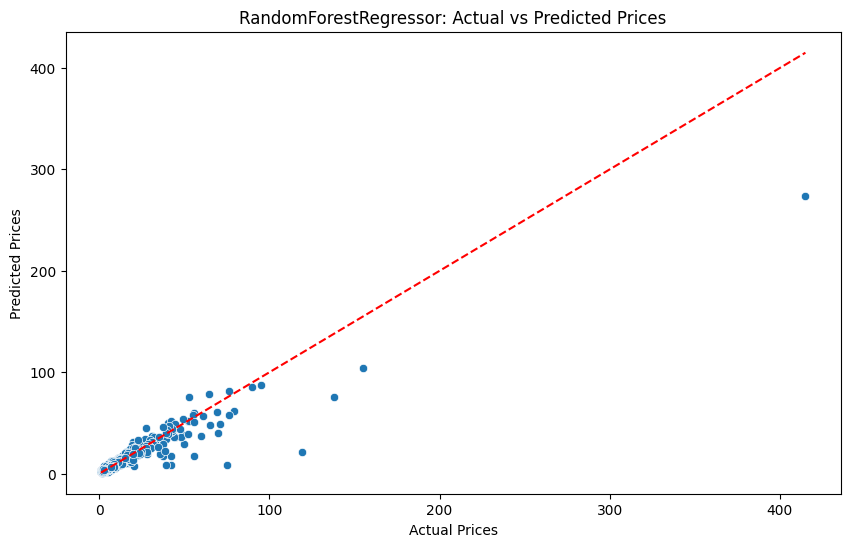

Model: DecisionTreeRegressor
Mean Squared Error: 35.98
Mean Absolute Error: 1.98
R2 Score: 0.89
----------------------------------------


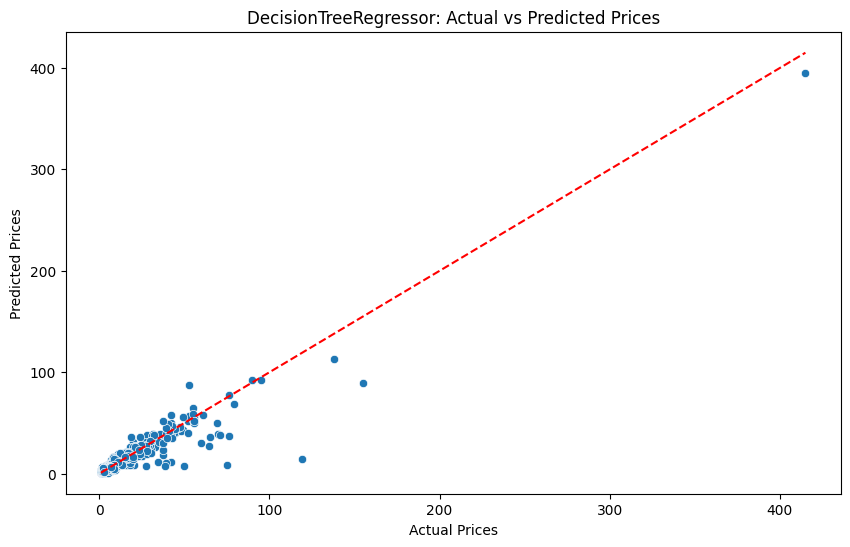

Model: GradientBoostingRegressor
Mean Squared Error: 42.35
Mean Absolute Error: 2.81
R2 Score: 0.87
----------------------------------------


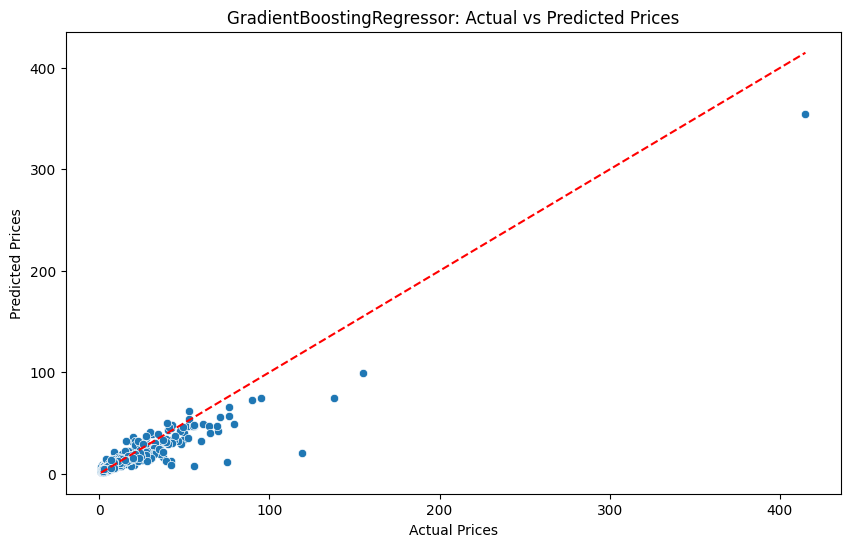

In [81]:
for model in models:
    evaluate_model(model, x_train, y_train, x_test, y_test)

In [82]:
Final_model = RandomForestRegressor(random_state=42)  
Final_model.fit(x_train, y_train)     
y_pred=Final_model.predict(x_test)
print(mean_squared_error(y_test,y_pred)) 
print(mean_absolute_error(y_test,y_pred)) 
print(r2_score(y_test,y_pred))

45.58877562103149
1.7819281551441357
0.8556802003311017


In [83]:
import pickle
with open('Final_model.pkl', 'wb') as file:
    pickle.dump(Final_model, file)
    

In [84]:
with open('Label_encoder.pkl', 'wb') as file:
    pickle.dump(encoders, file)

In [85]:
encoders

{'Body_Type': LabelEncoder(),
 'Fuel_Type': LabelEncoder(),
 'City': LabelEncoder()}

In [86]:
with open('Onehot_encoder.pkl', 'wb') as file:
    pickle.dump(oe, file)

In [87]:
with open('minmaxscaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)